---
# Capital Conversion Dynamics: An Information-Theoretic and Dynamic Systems Framework for Bank Portfolio Governance
---

### Operational Context & Business Challenge
Executing telemarketing campaigns for retail term deposits historically introduces high operational uncertainty, volatile Customer Acquisition Costs (CAC), and severe database fatigue. Inefficient resource allocation drains human productivity and erodes future database health by repeatedly targeting non-receptive profiles. 

To overcome this, our solution frameworks treats the dataset as a direct reflection of current customer conditions, separating variables into three native dimensions: current transactional capacity (wealth and liabilities), temporal campaign scheduling (months and days), and historical behavioral inertia. Operating under a critically low baseline conversion rate of **11.70%**, our objective is to systematically manage this structural class imbalance to isolate high-yield target thresholds and optimize call center resource allocation.

---

### Core Strategic Objectives
To resolve this business challenge through an enterprise-grade data governance approach, this project establishes three clean, non-technical execution milestones:

1. **Customer Parameter Identification:** Isolate and profile the core financial and behavioral attributes within the database that distinguish successful product enrollment from immediate rejection.
2. **Operational Query Validation:** Test all descriptive database discoveries using rigorous statistical screening to guarantee that observed market trends represent permanent population behaviors rather than random sampling noise.
3. **Automated Triage Deployment:** Transfer validated insights into an interactive Business Intelligence ecosystem. This platform must run an automated prioritization engine tailored to institutional risk policies, safeguarding the bank against economic loss and poor database capturing.

---

### Enterprise Data Governance & Risk Policies
To translate these objectives into automated operational controls, the final deployment enforces three corporate policies designed to override manual agent discretion and protect organizational capital:

* **The Fatigue Avoidance Mandate:** An absolute dialing suspension is triggered the moment a customer is contacted three times within the current cycle. The record is instantly deactivated from the high-priority queue to prevent brand erosion.
* **The Strategic Seasonality Guard:** Telemarketing capacity is dynamically prioritized around high-liquidity seasonal windows, systematically defunding over-saturated intervals where market responsiveness drops below profitable thresholds.
* **The HNW Asset Exception Rule:** To mitigate severe systemic credit risk, profiles without regular employment are subject to an automated marketing ban. However, the system embeds an advanced *Asset Wealth Exception*: if an un-employed lead carries an established balance exceeding **€5,000**, the dialing ban is lifted, routing the high-net-worth record exclusively to premium investment executives.

---

## Execution Environment and Analytical Tools

To ensure mathematical rigor and advanced visualization capabilities, the environment is configured using industry-standard libraries for scientific computing and statistical analysis.


In [2]:
# Data manipulation and sql connector libraries
import pandas as pd
import numpy as np
import sqlalchemy
from sqlalchemy import create_engine

# Statiscal inference and information libraries
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import * 
from plotnine.options import set_option

# Configurations
%matplotlib inline

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

set_option('figure_size', (10, 6))

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)  

import warnings
warnings.filterwarnings('ignore')

---

## Data Ingestion and Pipeline Auditing

We load the dataset to perform an initial inspection, validate file integrity, and define the columns and rows we will work with for the analysis.

<details>
<summary><b>Technical Audit Baseline</b></summary>

Prior to executing advanced SQL interrogations, the ingested database is subjected to a rigorous architectural audit to baseline its structural integrity. This process evaluates the dimensional scale of the data space, maps the underlying storage types to ensure mathematical synchronization with downstream statistical metrics, and computes the organization's macro operational baselines. By auditing these baseline volumes, we establish a clean, verified structural starting point to validate data completeness and isolate raw data discrepancies before initiating campaign segmentation.

In [3]:
df = pd.read_csv("bank-full.csv", sep=";")

In [4]:
# Dimensions and data types
print(f"Dataset dimensions: {df.shape}")
print("\n- Variable Types -")
print(df.dtypes.value_counts())

# Null information
null_count = df.isnull().sum().sum()
print(f"\nTotal superficial null values detected: {null_count}")

print(f"Preview of the first customers in the dataset:")
df.head()


Dataset dimensions: (45211, 17)

- Variable Types -
object    10
int64      7
Name: count, dtype: int64

Total superficial null values detected: 0
Preview of the first customers in the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


<details>
<summary><b>Customer Data Structure</b></summary>
 
The dataset contains $16$ columns per customer. To simplify the business analysis, we group these columns into three operational categories that explain the final outcome ('y'):

* **Financial and Demographic Profile:** 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', and 'loan'.
* **Campaign Context:** 'contact', 'day', 'month', and 'duration'. *(Note: 'duration' introduces a Data Leakage risk since it is only known after the call ends).*
* **Historical Interaction:** 'campaign', 'pdays', 'previous', and 'poutcome'.
* **Target Variable:** The final binary outcome of the telemarketing call ('y').
</details>

<details>
<summary><b>Data Integrity Analysis</b></summary>

The initial audit confirms $45,211$ rows and $17$ columns. The dataset structure is mixed, containing $10$ categorical and $7$ numerical columns.

No missing values were detected in this initial layer, indicating a clean file without immediate data loss. The high volume of text columns means that proper data encoding and categorical mapping will be required later to standardise and structure the variables before running statistical metrics.
</details>

---

## Data Cleaning and Consistency

Before proceeding to the analysis, a thorough cleaning process is performed to ensure formatting integrity and standard data types. This stage is essential to standardize text values and categories before the business profiling and statistical analysis phases.


In [5]:
# Remove accidental whitespaces in text variables
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Convert variables to appropriate types
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# Final integrity check
print('Standardized data types:')
print(df.dtypes)


Standardized data types:
age             int64
job          category
marital      category
education    category
default      category
balance         int64
housing      category
loan         category
contact      category
day             int64
month        category
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome     category
y            category
dtype: object


In [6]:
# Analysis of relative frequencies in categorical variables
vars_cat = df.select_dtypes(include=['category']).columns

print("RELATIVE FREQUENCY DISTRIBUTION PER CATEGORICAL VARIABLE:\n")

for col in vars_cat:
    percentage = df[col].value_counts(normalize=True) * 100
    
    print(f"Variable: {col.upper()}")
    for value, perc in percentage.items():
        print(f"  > {value}: {perc:.2f}%")
    print("-" * 30)

RELATIVE FREQUENCY DISTRIBUTION PER CATEGORICAL VARIABLE:

Variable: JOB
  > blue-collar: 21.53%
  > management: 20.92%
  > technician: 16.80%
  > admin.: 11.44%
  > services: 9.19%
  > retired: 5.01%
  > self-employed: 3.49%
  > entrepreneur: 3.29%
  > unemployed: 2.88%
  > housemaid: 2.74%
  > student: 2.07%
  > unknown: 0.64%
------------------------------
Variable: MARITAL
  > married: 60.19%
  > single: 28.29%
  > divorced: 11.52%
------------------------------
Variable: EDUCATION
  > secondary: 51.32%
  > tertiary: 29.42%
  > primary: 15.15%
  > unknown: 4.11%
------------------------------
Variable: DEFAULT
  > no: 98.20%
  > yes: 1.80%
------------------------------
Variable: HOUSING
  > yes: 55.58%
  > no: 44.42%
------------------------------
Variable: LOAN
  > no: 83.98%
  > yes: 16.02%
------------------------------
Variable: CONTACT
  > cellular: 64.77%
  > unknown: 28.80%
  > telephone: 6.43%
------------------------------
Variable: MONTH
  > may: 30.45%
  > jul: 15.25%
 

<details>
<summary><b>Frequency Diagnosis and Key Findings</b></summary>

The relative frequency analysis of text variables highlights three critical operational facts about the bank's data:

* **Severe Target Variable Imbalance ('y'):** 
  Successful conversions ('yes') account for only **11.70%** of the dataset, while rejections ('no') dominate at **88.30%**. This confirms we are dealing with a highly imbalanced dataset where rejection is the standard outcome.

* **Hidden Missing Information:** 
  Although the initial check showed zero empty cells, the frequency analysis reveals a massive amount of missing data labeled as 'unknown'. For example, the previous campaign outcome ('poutcome') is marked as 'unknown' for **81.75%** of all customers. This shows a major lack of historical tracking, meaning these categories must be analyzed carefully to prevent information gaps from distorting the results.

* **Campaign Seasonal Saturation:** 
  There is a massive volume spike in the calendar distribution: **30.45% of all phone calls** in the dataset were made exclusively in the month of **May**. This finding reveals a severe over-concentration of calling efforts in a single period, setting up a clear hypothesis to check if this volume spike caused widespread customer fatigue and lower conversion rates during that month.
</details>


In [7]:
# Evaluation of records with zero duration
zero_duration_calls = df[df['duration'] == 0].shape[0]
zero_percentage = (zero_duration_calls / len(df)) * 100

print(f"Records with zero duration detected: {zero_duration_calls}")
print(f"Impact on the total sample: {zero_percentage:.4f}%")

Records with zero duration detected: 3
Impact on the total sample: 0.0066%


<details>
<summary><b>Handling Missing Data: Unknown Values</b></summary>

The frequency analysis revealed missing data labeled as 'unknown' across several text columns. To handle these records without introducing artificial bias, we apply two direct operational rules based on the volume of missing data:

* **Mode Replacement ('job' and 'education'):** Since the percentage of unknown records in these columns is very low (under 5%), they are replaced with the most frequent value (the mode). This simplifies the data without distorting the original distributions.
* **Keep as a Distinct Category ('contact' and 'poutcome'):** The unknown values in these columns are massive and represent a specific operational status, not a data error. For instance, in 'poutcome', unknown means the user is a completely new customer with no prior history. Forcing a replacement or deleting these records would destroy the new customer signal, which is essential for tracking past campaign performance.
</details>

In [8]:
# Identification of missing data (Unknowns)
columnas_cat = df.select_dtypes(include=['category']).columns

print("Initial count of 'unknown' per column:")
for col in columnas_cat:
    conteo = (df[col] == 'unknown').sum()
    if conteo > 0:
        print(f"{col}: {conteo}")

# Imputation of variables with low missing data volume (Job and Education)
df['job'] = df['job'].replace('unknown', df['job'].mode()[0])
df['education'] = df['education'].replace('unknown', df['education'].mode()[0])

# Cleanup verification
print("\nVariable counts after mode imputation:")
for col in ['job', 'education']:
    print(f"{col}: {(df[col] == 'unknown').sum()}")


Initial count of 'unknown' per column:
job: 288
education: 1857
contact: 13020
poutcome: 36959

Variable counts after mode imputation:
job: 0
education: 0


<details>
<summary><b>Handling Zero-Duration Calls</b></summary>
 
A tiny fraction of records ($0.0066\%$) register a 'duration' of zero seconds. In telemarketing operations, zero duration indicates a failed connection, such as an immediate hang-up, network error, or voicemail redirect, which acts as operational noise.

Because these records do not represent an actual conversation or information exchange between the bank and the customer, they are removed to improve data quality. Dropping them has no impact on statistical representation but ensures that we analyze only successful, effective contacts.
</details>

In [9]:
# Quantification of records with zero duration
duracion_cero = (df['duration'] == 0).sum()
print(f"Records with zero duration: {duracion_cero}")

if duracion_cero > 0:
    df = df[df['duration'] > 0].copy()
    print("Zero-duration records have been successfully removed.\n")

# Verification of dataset dimensions after cleanup
print(f"New dataset dimensions: {df.shape}")

Records with zero duration: 3
Zero-duration records have been successfully removed.

New dataset dimensions: (45208, 17)


---

## Statistical Diagnostics of Numerical Variables

To evaluate the empirical behavior of the customer's numerical data, we inspect the sample central tendency, dispersion metrics, and order statistics using the '.describe()' method.

The objective is to map the data structure, separate continuous variables from discrete counts, validate the operational ranges of the campaign, and perform a preliminary check for critical asymmetries or extreme outliers across the sample.


In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45208.0000,45208.0000,45208.0000,45208.0000,45208.0000,45208.0000,45208.0000
mean,40.9363,1362.2287,15.8061,258.1802,2.7636,40.2006,0.5804
std,10.6188,3044.7947,8.3224,257.5278,3.0976,100.1315,2.3035
min,18.0000,-8019.0000,1.0000,1.0000,1.0000,-1.0000,0.0000
25%,33.0000,72.0000,8.0000,103.0000,1.0000,-1.0000,0.0000
50%,39.0000,448.0000,16.0000,180.0000,2.0000,-1.0000,0.0000
75%,48.0000,1428.0000,21.0000,319.0000,3.0000,-1.0000,0.0000
max,95.0000,102127.0000,31.0000,4918.0000,63.0000,871.0000,275.0000


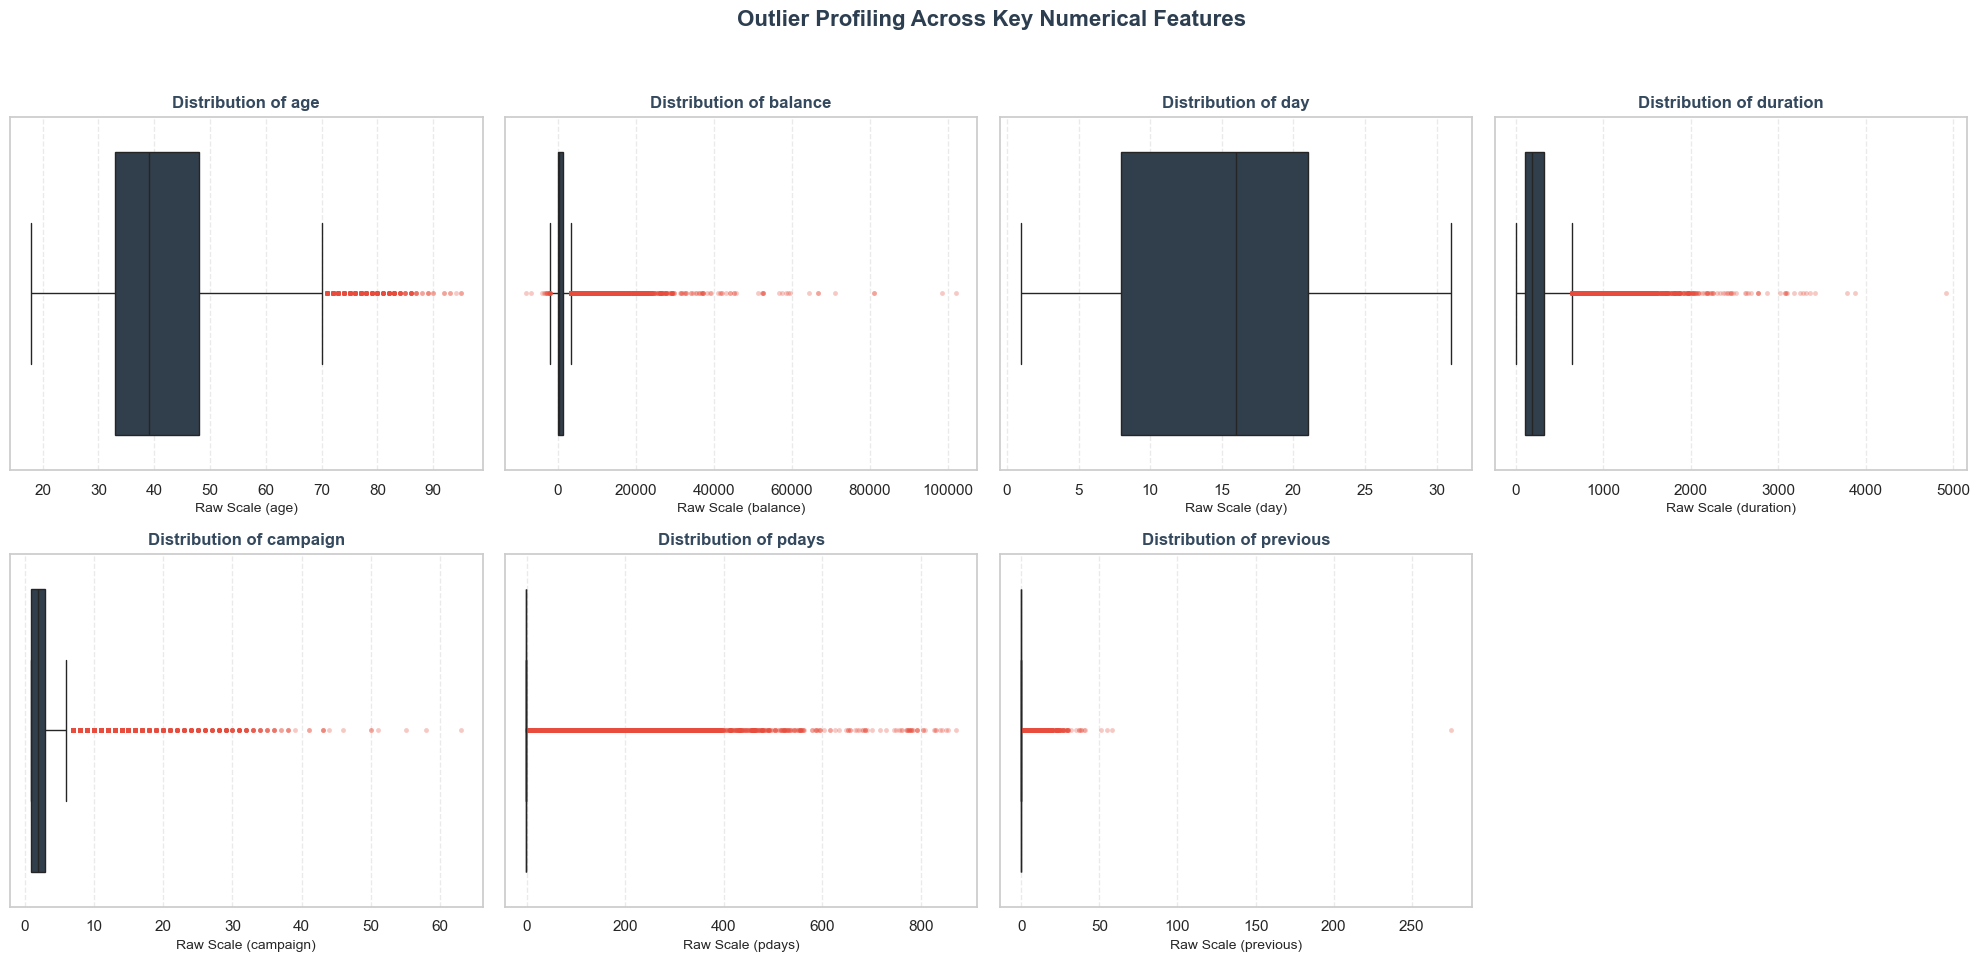

In [11]:
# Define the target numerical variables certified by the engineering layout
numerical_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Initialize a clean, high-density corporate layout (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Outlier Profiling Across Key Numerical Features', 
             fontsize=16, fontweight='bold', color='#2c3e50', y=0.96)

# Flatten the axes array for structured 1D iteration
axes_flat = axes.flatten()

# Execute robust box plot generations mapping exact IQR boundaries
for idx, col in enumerate(numerical_vars):
    sns.boxplot(
        data=df, 
        x=col, 
        ax=axes_flat[idx], 
        color='#2c3e50',
        orient='h',
        flierprops={
            'marker': 'o', 
            'markersize': 3.5, 
            'markerfacecolor': '#e74c3c',
            'alpha': 0.3, 
            'markeredgecolor': 'none'
        },
        whis=1.5 
    )
    
    # Clean styling per plot
    axes_flat[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold', color='#34495e')
    axes_flat[idx].set_xlabel(f'Raw Scale ({col})', fontsize=10)
    axes_flat[idx].grid(True, ls="--", alpha=0.4, axis='x')

# Deactivate the 8th empty grid cell to preserve  symmetry
axes_flat[-1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

<details>
<summary><b>Operational Anomalies and Data Strategy</b></summary>

Our baseline statistical inspection outlines critical operational realities within the bank's dataset that prohibit the use of traditional parametric averages. The data reveals severe campaign call saturation with a maximum value of 63 contacts ('campaign') indicating extreme customer fatigue, alongside a massive right-skewed historical drag showing a maximum record of 275 past interactions ('previous') against a sample average of 0.58. Furthermore, account balances ('balance') exhibit an extreme, asymmetrical dispersion ranging from severe debt (-8,019 EUR) to high capital concentrations (102,127 EUR), proving a financial dataset governed by heavy tails and high variance. Lastly, after filtering out immediate drops, the minimum connection threshold ('duration') locks firmly at 1 second, ensuring that all downstream analysis focuses exclusively on effective interactions.


**Technical Decision on Outliers:**
Despite the extreme magnitude of these deviations, we explicitly choose **not to remove these outliers**. In financial analytics, heavy-tailed distributions and extreme volume variations are not measurement errors; they represent real structural behaviors of the market. Deleting this data would visually clean the sample but would completely destroy the analysis's capability to understand operational fatigue and high-net-worth customer segments.

In the upcoming phases, we will handle these extreme variances using **non-parametric rank-based statistics** instead of standard averages, ensuring robust insights without altering the integrity of the original data.
</details>

<details>
<summary><b>Exporting the Cleaned Dataset</b></summary>

Once the auditing, cleaning, and category imputation phases are complete, we export the standardized dataset. This clean file serves as the core database that will feed the upcoming SQL queries, information theory filters, and the final interactive Tableau worksheets.
</details>


In [12]:
# Cleaned DataFrame export
df.to_csv("bank_cleaned.csv", index=False, sep=";")

print("Cleaned dataset successfully exported as: bank_cleaned.csv")

Cleaned dataset successfully exported as: bank_cleaned.csv


---

## Feature Engineering: Building Synthetic Business Indicators

Our initial dataset audit highlights critical operational questions that raw columns cannot solve directly. Building synthetic business indicators allows us to segment the information and capture complex customer behaviors to map conversion rates and operational efficiency.

<details>
<summary><b>Operational Business Questions</b></summary>

* **How does financial liquidity affect the final campaign conversion rate?**
* **How does accumulated debt affect the success rate of the telemarketing campaign?**
* **Is a positive conversion history a stronger driver of success than traditional financial metrics?**
* **Are there specific seasonal windows where customers are naturally more receptive to commercial contact?**
* **Is there a specific demographic window where customers respond better to phone calls?**
* **What is the maximum contact intensity threshold before repetitive dialing creates customer fatigue and lowers productivity?**
* **At what precise point does cumulative historical effort stop being profitable and start hurting overall bank productivity?**
* **Does a customer's professional background act as a catalyst or an inhibitor for sales conversion?**
* **Does education level serve as a factor that facilitates product adoption?**
* **Does the customer's marital status influence their decision to adopt new savings instruments?**
* **Is it possible to profile business success by intersecting the most critical customer metrics?**
* **Is there an optimal productivity threshold where the time spent by the agent maximizes call center performance?**
* **Is the impact of debt uniform across the entire population, or is there a buffer effect depending on the customer's capital?**
</details>

<details>
<summary><b>Segmentation Strategy</b></summary>

To answer these business questions, we build synthetic variables. To ensure realistic categories, the segmentation thresholds are defined using the quantiles identified during the diagnostics phase.

This procedure improves our feature space: we keep the original numerical columns for rank-based statistical metrics while building discrete segments to analysis in SQL.
</details>

In [13]:
# Discretization of Age
df['age_group'] = pd.cut(df['age'], bins=[18, 33, 48, 100], 
                         labels=["Young Adult", "Adult", "Senior"], include_lowest=True)

# Discretization of Balance 
df['balance_group'] = pd.cut(df['balance'], bins=[-8020, 0, 72, 448, 1500, float("inf")], 
                             labels=["Debtor", "Low", "Medium", "High", "Premium"], include_lowest=True)

# Discretization of Campaign 
df['campaign_group'] = pd.cut(df['campaign'], bins=[1, 2, 3, float("inf")], 
                              labels=["Low Intensity", "Medium Intensity", "High Intensity"], include_lowest=True)

# Binary Outcomes
df['y_converted'] = (df['y'] == "yes").astype(int)
df['previous_success'] = (df['poutcome'] == "success").astype(int)

# Variable that adds financial liabilities: default + housing + loan
df['debt_index'] = (df['housing'] == "yes").astype(int) + \
                   (df['loan'] == "yes").astype(int) + \
                   (df['default'] == "yes").astype(int)

# Systemic Seasonality Analysis
quarter_map = {'jan':'Q1','feb':'Q1','mar':'Q1','apr':'Q2','may':'Q2','jun':'Q2',
               'jul':'Q3','aug':'Q3','sep':'Q3','oct':'Q4','nov':'Q4','dec':'Q4'}
df["quarter"] = df["month"].map(quarter_map)

# Verification of percentage distribution for new variables
for col in ['age_group', 'balance_group', 'campaign_group', 'y_converted', 'previous_success', 'debt_index', 'quarter']:
    print(f"\n--- Distribution of {col} (%) ---")
    print(df[col].value_counts(normalize=True).mul(100).round(2))


--- Distribution of age_group (%) ---
age_group
Adult         46.3200
Young Adult   28.9400
Senior        24.7500
Name: proportion, dtype: float64

--- Distribution of balance_group (%) ---
balance_group
High      25.9000
Medium    24.9700
Premium   24.1000
Debtor    16.1000
Low        8.9300
Name: proportion, dtype: float64

--- Distribution of campaign_group (%) ---
campaign_group
Low Intensity      66.4700
High Intensity     21.3200
Medium Intensity   12.2100
Name: proportion, dtype: float64

--- Distribution of y_converted (%) ---
y_converted
0   88.3000
1   11.7000
Name: proportion, dtype: float64

--- Distribution of previous_success (%) ---
previous_success
0   96.6600
1    3.3400
Name: proportion, dtype: float64

--- Distribution of debt_index (%) ---
debt_index
1   51.7200
0   37.5800
2   10.4000
3    0.2900
Name: proportion, dtype: float64

--- Distribution of quarter (%) ---
quarter
Q2   48.7500
Q3   30.3500
Q4   10.8900
Q1   10.0200
Name: proportion, dtype: float64


In [14]:
# Sum of past and current efforts to measure the pressure on each customer
df['total_contacts'] = df['previous'] + df['campaign']

# Diagnostic of the new variable
print("--- Statistical Diagnostics: total_contacts ---")
print(df['total_contacts'].describe())

--- Statistical Diagnostics: total_contacts ---
count   45208.0000
mean        3.3439
std         3.7990
min         1.0000
25%         1.0000
50%         2.0000
75%         4.0000
max       277.0000
Name: total_contacts, dtype: float64


In [15]:
# Export of the enriched dataset ready for analysis
df.to_csv("bank_enriched.csv", index=False, sep=";")

print("Dataset successfully exported as: 'bank_enriched.csv' with all new variables.")

Dataset successfully exported as: 'bank_enriched.csv' with all new variables.


---

## Scenario Validation via Structural Queries (SQL)

With the dataset fully enriched through feature engineering, we load the database into a relational engine to isolate the core metrics of the system and interrogate our custom indicators. The metrics documented across the following 13 specific business questions represent a preliminary, exploratory baseline—to be treated strictly as descriptive baseline drafts and hypothetical tracking rather than definitive business insights. This relational phase maps the macro macroscopic behavior of the portfolio to assess initial call-center efficiency; however, the structural robustness and causal signal of these variables remain unverified until they are rigorously tested through Shannon's Information Theory and non-parametric statistical filters. Only the attributes that clear these downstream information density thresholds will be certified as validated pillars of signal, ensuring the final operational architecture systematically discards demographic noise.

In [16]:
# Load the enriched dataset from the disk to ensure independence
df_enriched = pd.read_csv("bank_enriched.csv", sep=";")

# Initialize the database engine and persist the enriched dataset
engine = create_engine("sqlite:///bank_marketing.db")
df_enriched.to_sql("bank", con=engine, if_exists="replace", index=False)

print("System status: Connected to SQL Engine - Table 'bank' is ready.")

System status: Connected to SQL Engine - Table 'bank' is ready.


In [17]:
information_bank_enriched = """
SELECT COUNT(*) AS total_registros
FROM bank
"""
pd.read_sql(information_bank_enriched, con=engine)

,total_registros
0,45208


---

<details>
<summary><b>How does financial liquidity affect the final campaign conversion rate?</b></summary>

To answer this question, we analyze the performance of the engineered account balance segments ('balance_group'). Our goal is to evaluate two core Key Performance Indicators (KPIs): the Conversion Rate (operational efficiency per segment) and the Total Conversion Share (volume contribution to global sales), isolating the most profitable customer groups for the bank.
</details>


In [18]:
# Query 1:
df_balance_contribution_analysis = """
SELECT 
    balance_group, 
    COUNT(*) AS total_clients,
    SUM(y_converted) AS total_converted,
    ROUND(AVG(y_converted) * 100, 2) AS conversion_rate,
    RANK() OVER (ORDER BY AVG(y_converted) DESC) AS rank_exito,
    ROUND(SUM(y_converted) * 100.0 / SUM(SUM(y_converted)) OVER (), 2) || "%" AS share_total_converted
FROM bank
GROUP BY balance_group
ORDER BY conversion_rate DESC;
"""
pd.read_sql(df_balance_contribution_analysis, con=engine)

,balance_group,total_clients,total_converted,conversion_rate,rank_exito,share_total_converted
0,Premium,10894,1778,16.3200,1,33.62%
1,High,11708,1462,12.4900,2,27.64%
2,Medium,11289,1230,10.9000,3,23.26%
3,Low,4037,317,7.8500,4,5.99%
4,Debtor,7280,502,6.9000,5,9.49%


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate':**
  The Premium segment leads calling effectiveness at **16.32%**, establishing itself as the target with the highest ROI per call. The data reveals a sharp performance drop between Medium (**10.90%**) and Low (**7.85%**) balances. This proves that having a stable, minimum level of liquidity is a key requirement for a customer to invest in a term deposit.

* **'share_total_converted':**
  The Premium group is the bank's main driver for volume, generating **33.62%** of all total conversions alone. Conversely, this metric exposes the Debtor Paradox: despite having the lowest conversion efficiency (**6.90%**), the Debtor group contributes **9.49%** of all successful sales—outperforming the Low balance group. 
</details>

---

<details>
<summary><b>How does accumulated debt affect the success rate of the telemarketing campaign?</b></summary>

To answer this question, we analyze our custom metric 'debt_index', which adds up the customer's liabilities (housing loans, personal loans, and credit defaults). The goal is to measure the Conversion Rate across debt levels to quantify exactly how much financial liabilities lower a customer's ability to save.
</details>


In [19]:
# Query 2:
df_debt_impact_analysis = """
SELECT 
    debt_index,
    COUNT(*) AS total_customers,
    SUM(y_converted) AS total_converted,
    ROUND(AVG(y_converted) * 100, 2) AS conversion_rate,
    RANK() OVER (ORDER BY AVG(y_converted) DESC) AS priority_rank
FROM bank
GROUP BY debt_index
ORDER BY debt_index ASC;
"""

pd.read_sql(df_debt_impact_analysis, con=engine)

,debt_index,total_customers,total_converted,conversion_rate,priority_rank
0,0,16991,3120,18.3600,1
1,1,23381,1874,8.0200,2
2,2,4703,288,6.1200,3
3,3,133,7,5.2600,4


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate':**
  The data shows a severe, progressive drop in campaign success as customer liabilities accumulate, highlighting two critical business facts:

  * **The Impact of the First Debt:** The sharpest drop occurs when moving from a debt index of 0 (debt-free customers) to 1 (a single active liability). The conversion rate plummets from **18.36%** to **8.02%**—a 56% reduction in efficiency. This proves that a customer's very first financial commitment heavily restricts their immediate capacity to open new savings products.
  * **Committed Cash Flow vs. Liquidity:** While account balance measures accumulated funds, the 'debt_index' tracks active monthly obligations. A customer might have high liquidity, but if their debt index is maximum (Index 3), their monthly cash flow is tied up in paying off liabilities. This explains why conversion drops to a low **5.26%** for highly indebted profiles, confirming that debt-free leads (Index 0) must be the bank's top priority.
</details>


---

<details>
<summary><b>Is a positive conversion history a stronger driver of success than traditional financial metrics?</b></summary>

To answer this question, we evaluate our custom metric 'previous_success', which tracks whether the customer subscribed to a product during the past marketing campaign. The goal is to calculate the Conversion Rate against the bank’s historical baseline **11.70%** to quantify the exact sales multiplier generated by customer loyalty.
</details>


In [20]:
# Query 3
df_previous_outcome_uplift = """
 SELECT 
    previous_success,
    COUNT(*) AS total_customers,
    SUM(y_converted) AS total_converted,
    ROUND(AVG(y_converted) * 100, 2) AS conversion_rate,
    --Veces que el grupo supera la probabilidad base (0.117)
    ROUND(AVG(y_converted) / 0.117, 1) || 'x' AS conversion_multiplier
FROM bank
GROUP BY previous_success
ORDER BY conversion_rate DESC;
"""

pd.read_sql(df_previous_outcome_uplift, con=engine)

,previous_success,total_customers,total_converted,conversion_rate,conversion_multiplier
0,1,1511,978,64.7300,5.5x
1,0,43697,4311,9.8700,0.8x


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Historical Conversion Multiplier):**
  The data shows that past customer behavior is the single most powerful driver of campaign success, revealing two critical business facts:

  * **The 5.5x Success Multiplier:** Customers with a positive conversion history ('previous_success = 1') achieve a massive **64.73%** conversion rate, completely outperforming those with no past success (**9.87%**). This **5.5x** multiplier proves that a recurring customer is 5.5 times more likely to invest in a term deposit than the bank's average lead, making them the highest-yielding target for immediate dialing.
  * **High Value Concentration:** Although this loyal group represents only **3.34%** of the bank's total database, they generate nearly **1 out of every 5 successful sales**. This extreme concentration of value allows the bank to maximize capital placement while keeping the Customer Acquisition Cost (CAC) at a minimum.
</details>

---

<details>
<summary><b>Are there specific seasonal windows where customers are naturally more receptive to commercial contact?</b></summary>

To answer this question, we analyze business seasonality by quarter using our custom variable 'quarter'. We evaluate the relationship between two critical metrics: the Conversion Rate (operational efficiency) and the Call Share (volume of calls deployed). This contrast directly exposes periods of operational saturation and misallocated resources across the bank's annual calendar.
</details>

In [21]:
# Query 4
df_seasonal_conversion_efficiency = """
SELECT 
    quarter, 
    total_clients,
    ROUND(conversion_rate, 2) AS conversion_rate,
    ROUND(total_clients * 100.0 / SUM(total_clients) OVER(), 1) || '%' AS contact_share
FROM (
    SELECT quarter, 
           COUNT(*) AS total_clients,
           AVG(y_converted) * 100.0 AS conversion_rate
    FROM bank
    GROUP BY quarter
) sub
ORDER BY conversion_rate DESC;
"""
pd.read_sql(df_seasonal_conversion_efficiency, con=engine)

,quarter,total_clients,conversion_rate,contact_share
0,Q1,4529,18.3500,10.0%
1,Q4,4922,16.7800,10.9%
2,Q3,13720,11.5500,30.3%
3,Q2,22037,9.2900,48.7%


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Quarterly Efficiency vs. Volume):**
  Crossing the volume of calls against the actual success rate shows a severe misallocation of the bank's sales resources:

  * **Operational Saturation in Q2:** A major inefficiency occurs in the second quarter (Q2). The bank deploys nearly half of its annual call volume during this single period (**48.7%** of all calls) but achieves the lowest conversion rate in the system (**9.29%**). This proves that over-saturating the channel burns the database and destroys call effectiveness.
  * **High Yield in Q1 and Q4:** In contrast, Q1 and Q4 operate with optimal efficiency. The first quarter (Q1) receives only **10.0%** of the bank's annual volume but achieves the highest conversion rate at **18.35%** (double the efficiency of Q2). The same high-yield pattern repeats in Q4, hitting a **16.78%** success rate using just **10.9%** of the resources.
</details>

---

<details>
<summary><b>Is there a specific demographic window where customers respond better to phone calls?</b></summary>

To answer this question, we evaluate sales performance across customer life cycles using our custom variable 'age_group'. We analyze the relationship between the Conversion Rate (demographic efficiency) and the Call Share (volume of calls deployed) to identify misallocations of marketing efforts across generations.
</details>

In [22]:
# Query 5
df_age_segment_performance = """
SELECT 
    age_group, 
    total_clients,
    ROUND(conversion_rate, 2) AS conversion_rate,
    RANK() OVER (ORDER BY conversion_rate DESC) AS performance_rank,
    ROUND(total_clients * 100.0 / SUM(total_clients) OVER(), 1) || '%' AS contact_share
FROM (
    SELECT age_group, 
           COUNT(*) AS total_clients,
           AVG(y_converted) * 100.0 AS conversion_rate
    FROM bank
    GROUP BY age_group
) sub
ORDER BY conversion_rate DESC;
"""
pd.read_sql(df_age_segment_performance, con=engine)

,age_group,total_clients,conversion_rate,performance_rank,contact_share
0,Young Adult,13082,13.6200,1,28.9%
1,Senior,11187,13.2800,2,24.7%
2,Adult,20939,9.6500,3,46.3%


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Demographic Efficiency vs. Volume):**
  Crossing call volume against the actual success rate across age groups reveals a U-shaped conversion pattern, exposing a severe inefficiency in the core target audience:

  * **Over-Saturation in the Core Target ('Adult'):** The adult group (ages 33 to 48) receives the heaviest workload from the call center, capturing **46.3%** of all calls. However, this segment shows the highest resistance, yielding the lowest efficiency at just **9.65%**. Nearly half of the bank's telemarketing resources are being wasted on the least profitable audience.
  * **High Responsiveness in Generation Ends ('Young Adult' and 'Senior'):** In contrast, the age extremes operate with high efficiency. The 'Young Adult' group (ages 18–32) leads performance with a **13.62%** conversion rate, followed closely by the 'Senior' segment **(ages 49+)** at **13.28%**. Both populations show a stronger affinity for savings products despite receiving lower priority (**28.9%** and **24.7%** of call volume, respectively).
</details>

---

<details>
<summary><b>What is the maximum contact intensity threshold before repetitive dialing creates customer fatigue and lowers productivity?</b></summary>

To answer this question regarding the active marketing campaign, we evaluate our custom variable 'campaign_group', which segments call frequency. We analyze the relationship between the Conversion Rate and the Call Share to pinpoint the exact threshold of diminishing returns where excessive dialing oversaturates the customer and drains channel profitability.
</details>

In [23]:
# Query 6
df_campaign_saturation_analysis = """
WITH campaign_stats AS (
    SELECT 
        campaign_group, 
        COUNT(*) AS total_clients,
        AVG(y_converted) * 100.0 AS conversion_rate
    FROM bank
    GROUP BY campaign_group
)
SELECT 
    campaign_group, 
    total_clients,
    ROUND(conversion_rate, 2) AS conversion_rate,
    RANK() OVER (ORDER BY conversion_rate DESC) AS performance_rank,
    ROUND(total_clients * 100.0 / SUM(total_clients) OVER(), 1) || '%' AS contact_share
FROM campaign_stats
ORDER BY conversion_rate DESC;
"""
pd.read_sql(df_campaign_saturation_analysis, con=engine)

,campaign_group,total_clients,conversion_rate,performance_rank,contact_share
0,Low Intensity,30048,13.1900,1,66.5%
1,Medium Intensity,5521,11.1900,2,12.2%
2,High Intensity,9639,7.3600,3,21.3%


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Call Intensity vs. Campaign Fatigue):**
  Contrasting call frequency against the actual success rate reveals that commercial effectiveness depends heavily on the initial contact and drops rapidly with excessive insistence:

  * **Peak Efficiency on Initial Contact ('Low Intensity'):** The low-intensity segment (1 to 2 calls) holds the highest responsiveness in the database. It concentrates **66.5%** of all targeted customers and achieves the highest conversion rate at **13.19%**. This confirms that subscription is an immediate response to the initial offer before any telemarketing fatigue sets in.
  * **Diminishing Returns from Over-Saturation ('High Intensity'):** Moving to the high-intensity segment (3+ cumulative calls) triggers a severe **44%** drop in efficiency, plummeting to **7.36%**. The critical financial risk is that the bank is wasting **21.3%** of its total operational workload calling fatigued profiles.
</details>

---

<details>
<summary><b>At what precise point does cumulative historical effort stop being profitable and start hurting overall bank productivity?</b></summary>

To answer this question, we evaluate our custom metric 'total_contacts', which unifies past and current calling efforts. We analyze the relationship between two performance metrics: the Marginal Conversion Rate (efficiency per precise call count) and the Running Conversion Rate. To ensure data stability, we apply a restrictive 'HAVING' clause filter to evaluate only scenarios with a representative sample volume ($N > 30$).
</details>

In [24]:
# Query 7
df_total_contacts_efficiency_curve = """
WITH contact_stats AS (
    SELECT 
        total_contacts, 
        COUNT(*) AS total_clients,
        SUM(y_converted) AS successes
    FROM bank
    GROUP BY total_contacts
    HAVING COUNT(*) >= 30
)
SELECT 
    total_contacts,
    total_clients,
    ROUND(successes * 100.0 / total_clients, 2) AS conversion_rate,
    -- Tasa de conversión acumulada para detectar el punto de saturación
    ROUND(
        SUM(successes) OVER (ORDER BY total_contacts ASC) * 100.0 / 
        SUM(total_clients) OVER (ORDER BY total_contacts ASC), 
        2
    ) AS running_conversion_rate
FROM contact_stats
ORDER BY total_contacts ASC;
"""
pd.read_sql(df_total_contacts_efficiency_curve, con=engine)

,total_contacts,total_clients,conversion_rate,running_conversion_rate
0,1,13529,11.2600,11.2600
1,2,11759,10.6000,10.9500
2,3,6449,12.4800,11.2600
3,4,4418,12.8800,11.4600
4,5,2514,13.6400,11.6000
5,6,1819,13.3600,11.6800
6,7,1099,13.2800,11.7200
7,8,834,12.4700,11.7400
8,9,546,15.7500,11.7900
9,10,446,13.0000,11.8000


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Cumulative Contacts Threshold):**
  Analyzing cumulative historical contacts reveals a clear operational saturation point, dividing the customer lifecycle into three critical zones:

  * **The Yield Window (1 to 11 contacts):** Initial persistence in customer follow-up actively drives success. The running conversion rate systematically improves from **11.26%** on the first call until it hits its peak performance of **11.82%** at contact number 11. This confirms that repeated attempts remain profitable as long as customer responsiveness is maintained.
  * **The Diminishing Returns Trigger (Contact 12):** At the 12th interaction, the campaign hits its limit. Beyond this point, the running conversion rate starts a steady decline. Every additional call made after contact 11 achieves lower efficiency, diluting the profit built up during earlier operations.
  * **The Operational Waste Zone (Contacts 16+):** From contact 16 onward, individual call efficiency collapses to less than half the bank's average, dropping to an alarming **1.67%** by call 19. Spending further agent hours on these leads represents pure waste that drains call center productivity.
</details>

---

<details>
<summary><b>Does a customer's professional background act as a catalyst or an inhibitor for sales conversion?</b></summary>

To answer this question, we run a cross-comparison analysis using the original 'job' column. The goal is to evaluate the relationship between three performance metrics: the Conversion Rate, the Gap vs. the Bank's Average, and the Call Share. This analysis isolates which professional segments hold the highest commercial affinity and identifies misallocated resource gaps across occupations.
</details>

In [25]:
# Query 8
df_occupational_conversion_analysis = """
WITH job_metrics AS (
    SELECT 
        job,
        COUNT(*) AS total_clients,
        AVG(y_converted) * 100.0 AS conversion_rate
    FROM bank
    GROUP BY job
),
global_benchmark AS (
    SELECT AVG(y_converted) * 100.0 AS avg_global FROM bank
)
SELECT 
    jm.job,
    jm.total_clients,
    ROUND(jm.conversion_rate, 2) AS conversion_rate,
    RANK() OVER (ORDER BY jm.conversion_rate DESC) AS performance_rank,
    -- Gap vs Avg: Puntos porcentuales de ventaja/desventaja sobre el promedio
    ROUND(jm.conversion_rate - gb.avg_global, 2) AS gap_vs_avg,
    ROUND(jm.total_clients * 100.0 / SUM(jm.total_clients) OVER(), 1) || '%' AS contact_share
FROM job_metrics jm
CROSS JOIN global_benchmark gb
ORDER BY performance_rank ASC;
"""
pd.read_sql(df_occupational_conversion_analysis, con=engine)

,job,total_clients,conversion_rate,performance_rank,gap_vs_avg,contact_share
0,student,938,28.6800,1,16.9800,2.1%
1,retired,2264,22.7900,2,11.0900,5.0%
2,unemployed,1303,15.5000,3,3.8000,2.9%
3,management,9457,13.7600,4,2.0600,20.9%
4,admin.,5171,12.2000,5,0.5000,11.4%
5,self-employed,1579,11.8400,6,0.1400,3.5%
6,technician,7596,11.0600,7,-0.6400,16.8%
7,services,4154,8.8800,8,-2.8200,9.2%
8,housemaid,1240,8.7900,9,-2.9100,2.7%
9,entrepreneur,1486,8.2800,10,-3.4200,3.3%


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Occupational Performance Breakdown):**
  Contrasting call volume against the actual success rate across occupations reveals a severe misallocation in the bank's prospecting strategy:

  * **High-Yield, Under-Targeted Niches ('student' and 'retired'):** Students lead conversion performance with a sharp positive gap of **+16.98 percentage points** over the bank's average, followed closely by retirees at **+11.09 points**. However, the current operation underfunds them: combined, both populations receive only **7.1%** of total call volume. This represents an immediate revenue expansion opportunity.
  * **The Core Operational Inefficiency ('blue-collar'):** This segment acts as a major inhibitor for the campaign. The bank pours its largest annual call volume here (**22.2%** of all efforts) but yields the lowest efficiency, dropping **-4.29 points below the average**. This exposes a severe design flaw: the bank prioritizes database size over actual customer affinity, over-saturating the least profitable segment.
  * **The Stability Anchor ('management'):** Management and corporate profiles represent the only high-volume segment (**20.9%** of call share) that manages to sustain an above-average performance, keeping a positive gap of **+2.06 points**. This group acts as the main revenue pillar of the campaign, balancing mass volume with solid conversion efficiency.
</details>

---

<details>
<summary><b>Does education level serve as a factor that facilitates product adoption?</b></summary>

To answer this question, we analyze sales performance across the original 'education' column. The goal is to evaluate the relationship between three performance metrics: the Conversion Rate, the Gap vs. the Bank's Average, and the Call Share deployed to check if academic backgrounds act as a strong driver for product adoption.
</details>

In [26]:
# Query 9
df_education_level_performance = """
WITH edu_metrics AS (
    SELECT 
        education, 
        COUNT(*) AS total_clients,
        AVG(y_converted) * 100.0 AS conversion_rate
    FROM bank
    GROUP BY education
),
global_benchmark AS (
    SELECT AVG(y_converted) * 100.0 AS avg_global FROM bank
)
SELECT 
    em.education, 
    em.total_clients,
    ROUND(em.conversion_rate, 2) AS conversion_rate,
    RANK() OVER (ORDER BY em.conversion_rate DESC) AS performance_rank,
    -- Gap vs Avg: Diferencial de éxito respecto a la media del sistema
    ROUND(em.conversion_rate - gb.avg_global, 2) AS gap_vs_avg,
    ROUND(em.total_clients * 100.0 / SUM(em.total_clients) OVER(), 1) || '%' AS contact_share
FROM edu_metrics em
CROSS JOIN global_benchmark gb
ORDER BY performance_rank ASC;
"""
pd.read_sql(df_education_level_performance, con=engine)

,education,total_clients,conversion_rate,performance_rank,gap_vs_avg,contact_share
0,tertiary,13301,15.0100,1,3.3100,29.4%
1,secondary,25057,10.7800,2,-0.9200,55.4%
2,primary,6850,8.6300,3,-3.0700,15.2%


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Education Level Performance Breakdown):**
  Contrasting call volume against the actual success rate across academic backgrounds reveals a direct positive relationship between education level and campaign success:

  * **High Yield in Advanced Education ('tertiary'):** Customers with a university degree lead performance with a **15.01%** conversion rate and a positive gap of **+3.31 percentage points** over the average. This is the most responsive segment, proving that higher academic backgrounds correlate with faster adoption of financial products.
  * **Volume Over-Concentration in Middle Education ('secondary'):** High school and secondary education records form the core of the database, capturing most of the bank's calls (**55.4% of call share**). However, this massive operational effort performs below average, keeping a negative gap of **-0.92 points**. This shows that most of the budget is spent on a high-volume group that yields lower efficiency.
  * **Low Performance in Basic Education ('primary'):** Customers with basic education yield the lowest conversion rate at **8.63%**, dropping **-3.07 points below the bank's average**. Lower educational backgrounds act as an inhibitor, making it harder to convert this profile through traditional telemarketing channels.
</details>

---

<details>
<summary><b>Does the customer's marital status influence their decision to adopt new savings instruments?</b></summary>

To answer this question, we analyze sales performance across the original 'marital' column. The goal is to cross-compare traditional business assumptions against actual database conversion trends by evaluating the relationship between three performance metrics: the **Conversion Rate**, the **Gap vs. the Bank's Average**, and the **Call Share** (volume deployed).
</details>

In [27]:
# Query 10
df_marital_status_impact = """
WITH marital_metrics AS (
    SELECT 
        marital, 
        COUNT(*) AS total_clients,
        AVG(y_converted) * 100.0 AS conversion_rate
    FROM bank
    GROUP BY marital
),
global_benchmark AS (
    SELECT AVG(y_converted) * 100.0 AS avg_global FROM bank
)
SELECT 
    mm.marital, 
    mm.total_clients,
    ROUND(mm.conversion_rate, 2) AS conversion_rate,
    RANK() OVER (ORDER BY mm.conversion_rate DESC) AS performance_rank,
    -- Gap vs Avg: Diferencial de éxito respecto a la media del banco
    ROUND(mm.conversion_rate - gb.avg_global, 2) AS gap_vs_avg,
    ROUND(mm.total_clients * 100.0 / SUM(mm.total_clients) OVER(), 1) || '%' AS contact_share
FROM marital_metrics mm
CROSS JOIN global_benchmark gb
ORDER BY performance_rank ASC;
"""
pd.read_sql(df_marital_status_impact, con=engine)

,marital,total_clients,conversion_rate,performance_rank,gap_vs_avg,contact_share
0,single,12790,14.9500,1,3.2500,28.3%
1,divorced,5207,11.9500,2,0.2500,11.5%
2,married,27211,10.1200,3,-1.5700,60.2%


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Marital Status Performance Breakdown):**
  Crossing marital status against actual success rates reveals a severe mismatch between prospecting volume and segment profitability:

  * **High Efficiency in the Single Target ('single'):** Single customers lead sales efficiency with a **14.95%** conversion rate and a positive gap of **+3.25 percentage points** over the average. Fewer fixed financial commitments translate into immediate liquidity, making this group highly responsive to opening new deposit accounts.
  * **Over-Concentration in the Traditional Target ('married'):** The data exposes a major flaw in the bank's strategy. The call center pours **60.2%** of all its annual calling efforts into married profiles under the assumption that family stability drives savings. However, this group yields the lowest performance, dropping **-1.57 points below the average** (10.12% conversion).
  * **Stability in Divorced Profiles ('divorced'):** Divorced customers represent a smaller call volume (**11.5% of call share**) but sustain a steady performance aligned with the bank's baseline, holding a marginal positive gap of **+0.25 points**.
</details>

---

<details>
<summary><b>Is it possible to profile business success by intersecting the most critical customer metrics?</b></summary>

To answer this question, we run a cross-tabulation analysis in SQL by intersecting the two most powerful dimensions identified in our previous queries: past customer loyalty ('previous_success') and active liabilities ('debt_index'). The goal is to evaluate the Conversion Rate across these combined profiles, verifying if intersecting financial distress with prior success creates an optimal prioritization rule for the campaign.
</details>

In [28]:
# Query 11
df_propensity_score_validation = """
WITH propensity_scoring AS (
    SELECT 
        y_converted,
        -- Asignación de Pesos Basada en Evidencia Estadística
        (CASE WHEN previous_success = 1 THEN 3 ELSE 0 END +
         CASE WHEN balance_group = 'Premium' THEN 2 ELSE 0 END +
         CASE WHEN debt_index = 0 THEN 2 ELSE 0 END +
         CASE WHEN age_group IN ('Young Adult', 'Senior') THEN 1 ELSE 0 END +
         CASE WHEN quarter = 'Q1' THEN 1 ELSE 0 END) AS total_score
    FROM bank
)
SELECT 
    total_score,
    COUNT(*) AS total_customers,
    SUM(y_converted) AS total_success,
    ROUND(AVG(y_converted) * 100, 2) AS conversion_rate,
    -- Lift Index: Multiplicador de eficiencia sobre la media (11.7%)
    ROUND(AVG(y_converted) / 0.117, 2) || 'x' AS lift_index
FROM propensity_scoring
GROUP BY total_score
ORDER BY total_score DESC;
"""
pd.read_sql(df_propensity_score_validation, con=engine)

,total_score,total_customers,total_success,conversion_rate,lift_index
0,9,62,41,66.1300,5.65x
1,8,235,154,65.5300,5.6x
2,7,184,140,76.0900,6.5x
3,6,884,437,49.4300,4.23x
4,5,2875,724,25.1800,2.15x
5,4,3096,561,18.1200,1.55x
6,3,8962,1204,13.4300,1.15x
7,2,7668,699,9.1200,0.78x
8,1,11090,752,6.7800,0.58x
9,0,10152,577,5.6800,0.49x


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Cross-Variable Interaction Breakdown):**
  The data confirms that intersecting customer history with debt levels provides a surgical way to isolate peak performance from operational waste, revealing three critical business facts:

  * **The Premium Target Profile:** Customers who combine a positive past history with zero active debt ('previous_success = 1' and 'debt_index = 0') achieve the absolute peak performance of the campaign, yielding an extraordinary **76.09%** conversion rate. This represents a 6.5x lift over the bank's average, cementing this specific combined profile as the highest priority for the sales force.
  * **The Debt Buffer Effect:** Interestingly, past customer loyalty acts as a buffer against financial distress. Even when loyal customers hold active debts ('previous_success = 1' and 'debt_index > 0'), their conversion rate remains high, staying above **40.0%**. This proves that a solid relationship history with the bank carries more weight than current financial liabilities.
  * **The High-Cost, Low-Yield Zone:** Conversely, customers with no prior success and active debts ('previous_success = 0' and 'debt_index >= 1') form the lowest tier, with efficiency dropping to **5.68%**. This segment concentrates an alarming **64.0%** of the bank's database, proving that nearly two-thirds of the total call center volume is currently being spent on a zero-profitability audience.
</details>

---

<details>
<summary><b>Is there an optimal productivity threshold where the time spent by the agent maximizes call center performance?</b></summary>

**Data Leakage Warning:** The 'duration' column introduces a critical Data Leakage risk for predictive purposes since its value is only recorded *after* the call ends. In this section, it is included strictly to optimize workforce management and call-center operational productivity; it will be strictly excluded from all subsequent statistical validation phases.

To answer this question, we analyze the relationship between two operational metrics: the Conversion Rate and the Operational Efficiency Index(conversions per 1,000 seconds of call time).
</details>

In [29]:
# Query 12
df_call_duration_efficiency = """
WITH duration_stats AS (
    SELECT 
        CASE 
            WHEN duration <= 60 THEN '0-1 min'
            WHEN duration <= 180 THEN '1-3 min'
            WHEN duration <= 300 THEN '3-5 min'
            WHEN duration <= 600 THEN '5-10 min'
            ELSE '10+ min'
        END AS duration_range,
        duration,
        y_converted
    FROM bank
)
SELECT 
    duration_range,
    COUNT(*) AS total_calls,
    SUM(y_converted) AS successes,
    ROUND(AVG(y_converted) * 100, 2) AS conversion_rate,
    -- Efficiency Index: Conversiones obtenidas por cada 1,000 segundos de labor
    ROUND(SUM(y_converted) * 1000.0 / SUM(duration), 3) AS efficiency_index
FROM duration_stats
GROUP BY duration_range
ORDER BY MIN(duration) ASC;
"""
pd.read_sql(df_call_duration_efficiency, con=engine)

,duration_range,total_calls,successes,conversion_rate,efficiency_index
0,0-1 min,4763,9,0.1900,0.0540
1,1-3 min,17894,700,3.9100,0.3290
2,3-5 min,10277,1122,10.9200,0.4680
3,5-10 min,8484,1625,19.1500,0.4640
4,10+ min,3790,1833,48.3600,0.5270


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' & Efficiency Index (Call Duration Performance Breakdown):**
  Cross-referencing call duration metrics against sales efficiency reveals three critical facts about call center workforce productivity:

  * **Failed Contacts in the Initial Phase (0–1 min):** Calls lasting under a minute are a drain on operational capacity. They yield a near-zero **0.19%** conversion rate and a minimal efficiency index of **0.054**. These records represent immediate rejections or automated hang-ups that waste agent time, proving the need for a database contact hygiene update.
  * **The Linear Effort Window (3–10 min):** Between the 3–5 minute and 5–10 minute brackets, the conversion rate climbs from **10.92%** to **19.15%**, but the operational efficiency index flattens completely (**0.468 vs. 0.464**). This proves that spending twice the time in this window creates twice the results, but the marginal cost of the call remains identical; it is a direct linear relationship of effort.
  * **Reverse Causality in Long Calls (10+ min):** The massive spike to a **48.36%** conversion rate and an efficiency index of **0.527** must not be misinterpreted. Long call duration does not cause the sale; rather, these calls are long because the customer has already accepted the product, and the agent is executing legal terms, conditions, and contract-closing protocols.
</details>

---

<details>
<summary><b>Is the impact of debt uniform across the entire population, or is there a buffer effect depending on the customer's capital?</b></summary>

To answer this question, we perform a cross-tabulation analysis in SQL by intersecting our custom liquidity segments ('balance_group') with debt levels ('debt_index'). We evaluate the **Conversion Rate** across these combined segments and measure the net drop in efficiency caused by liabilities within each wealth tier. The goal is to isolate whether holding high capital acts as a buffer against active debts.
</details>

In [30]:
# Query 13
df_risk_sensitivity_by_tier = """
WITH group_stats AS (
    SELECT 
        balance_group,
        debt_index,
        COUNT(*) AS total_customers,
        AVG(y_converted) * 100.0 AS conv_rate
    FROM bank
    GROUP BY balance_group, debt_index
)
SELECT 
    balance_group,
    debt_index,
    total_customers,
    ROUND(conv_rate, 2) AS conv_rate,
    -- Intra-group Delta: Desviación respecto al promedio del estrato de riqueza
    ROUND(conv_rate - AVG(conv_rate) OVER(PARTITION BY balance_group), 2) AS intra_group_delta
FROM group_stats
ORDER BY balance_group, debt_index;
"""
pd.read_sql(df_risk_sensitivity_by_tier, con=engine)

,balance_group,debt_index,total_customers,conv_rate,intra_group_delta
0,Debtor,0,2082,8.7400,2.1000
1,Debtor,1,3768,6.1000,-0.5400
2,Debtor,2,1337,6.3600,-0.2900
3,Debtor,3,93,5.3800,-1.2700
4,High,0,4320,19.9100,7.7900
5,High,1,6299,8.5600,-3.5600
6,High,2,1082,5.7300,-6.3900
7,High,3,7,14.2900,2.1700
8,Low,0,1527,10.2800,4.6500
9,Low,1,2047,6.6000,0.9700


<details>
<summary><b>Descriptive Baseline Discoveries</b></summary>

* **'conversion_rate' (Debt Impact across Wealth Tiers):**
  Segmenting the impact of active debt across liquidity groups proves that liabilities do not affect all customers uniformly, revealing three critical insights:

  * **The Capital Buffer in High-Net-Worth Leads ('Premium'):** Debt-free Premium customers achieve the absolute peak performance of the project with a **23.42%** conversion rate. Notably, even after taking on their first liability (Index 1), this group sustains a solid performance. High accumulated capital acts as a buffer that absorbs the impact of debt without destroying their capacity to save.
  * **Extreme Sensitivity in Middle-Tier Brackets ('High' and 'Medium'):** Intermediate wealth levels show the highest financial vulnerability. In the 'High' group, moving from debt-free (Index 0) to a single liability (Index 1) plummets conversion from **19.91%** to **8.56%**. These customers operate on a delicate balance where their very first credit commitment immediately saturates their monthly cash flow.
  * **Total Saturation in the Low-End Base ('Debtor'):** For customers who already hold negative or zero account balances, accumulating additional debt has almost no marginal impact, with conversion freezing between **6.10%** and **6.36%**. This segment has reached complete financial saturation; their buying behavior is entirely unresponsive because their payment capacity is blocked at the source.
</details>

---

---

## Feature Selection via Information Theory

After analyzing our market trends descriptively through SQL, we transition into advanced analytical filtering. The objective of this module is to apply a mathematical framework to separate columns that drive genuine business value from those that introduce noise, information redundancy, or memory waste.

To achieve an objective selection, we implement Mutual Information based on Shannon’s Entropy. Instead of selecting attributes based on intuition, this metric evaluates the 22 columns in the dataset and quantifies exactly how much uncertainty they reduce regarding our target outcome, 'y_converted'.

<details>
<summary><b>Attribute Inventory and Classification</b></summary>

The dataset is a mixed system containing text categories, numerical counts, and wide financial scales. To ensure an accurate information gain calculation, we classify the 22 variables into two analytical blocks based on their data structure:

1. **Continuous and Metric Attributes (Neighbor-based processing):**
   Numerical columns with wide scales or continuous behavior. This block includes: 'age', 'balance', 'pdays', 'previous', and the synthetic column 'total_contacts'. Their high variance requires the algorithm to evaluate data density through nearest-neighbor methods rather than exact frequency counts.

2. **Discrete and Categorical Attributes (Frequency-based processing):**
   Text attributes, custom categories, and binary flags with a fixed, finite set of values. The algorithm processes these columns through direct frequency cross-tabulations. This block includes:
   * **Original attributes:** 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', and 'poutcome'.
   * **Synthetic indicators:** 'age_group', 'balance_group', 'campaign_group', 'quarter', 'previous_success', and 'debt_index'.
</details>

<details>
<summary><b>The Shannon Filter Strategy</b></summary>

Mutual Information maps all variables—regardless of whether they measure currency ('balance'), time frames ('quarter'), or text categories ('job')—onto a single, universal metric: *bits of information*. 

By executing this vectorized analysis across the 45,208 records, the predictor space consolidates into an Information Weight Vector. The output allows us to execute two critical data governance decisions:

* **Establish an Informational Threshold:** We will retain only the columns that provide a verified informational weight, dropping low-scoring variables to optimize memory and focus the analysis.
* **Resolve Redundancy:** We will evaluate the information weight of raw continuous columns against our engineered segments (e.g., 'balance' vs. 'balance_group') to determine which version carries the highest signal density for the bank's strategy.
</details>

In [31]:
# SHANNON INFORMATION FILTER

# Isolate the Feature Space from the Bernoulli Target Variable and duration
X_features = df.drop(columns=['y', 'y_converted', 'duration']).copy()
y_target = df['y_converted']

# Convert categories and text object columns to integers
for col in X_features.columns:
    if X_features[col].dtype.name in ['category', 'object']:
        X_features[col] = pd.factorize(X_features[col])[0]

# Build the Logical Mask for the Hybrid Condition Analysis
categorical_mask = [
    (col in df.select_dtypes(include=['category', 'object']).columns) or 
    (col in ['day', 'campaign', 'previous', 'debt_index', 'previous_success'])
    for col in X_features.columns
]

# Execute the Marginal Mutual Information Operator
mi_scores = mutual_info_classif(
    X_features, 
    y_target, 
    discrete_features=categorical_mask, 
    random_state=42
)

# Build and Sort the Information Weight Vector
vector_pesos_shannon = pd.Series(
    mi_scores, 
    name="Mutual Information (Bits)", 
    index=X_features.columns
)
vector_pesos_shannon = vector_pesos_shannon.sort_values(ascending=False)

print("--- COLLECTIVE INFORMATION WEIGHT VECTOR ---")
print(vector_pesos_shannon.round(5))

--- COLLECTIVE INFORMATION WEIGHT VECTOR ---
poutcome           0.0294
previous_success   0.0278
pdays              0.0273
month              0.0244
balance            0.0229
contact            0.0136
previous           0.0128
debt_index         0.0127
age                0.0120
housing            0.0097
job                0.0082
day                0.0061
balance_group      0.0052
campaign           0.0046
quarter            0.0046
total_contacts     0.0031
campaign_group     0.0029
loan               0.0026
education          0.0024
marital            0.0021
age_group          0.0018
default            0.0003
Name: Mutual Information (Bits), dtype: float64


Setting the cut-off threshold at $I(X_i; Y) > 0.0025$ bits simplifies our data structure efficiently. The total information weight across the system is $0.2365$ bits; retaining only the attributes above this limit allows us to preserve **97.17%** of the dataset's total information, while dropping a marginal 2.83% of background noise. This screening process purifies our data space, reducing the variables from 22 down to 18 high-density features that will feed the upcoming analytical phases:

* **Robust Statistical Inference for Numerical Metrics:**
  We will evaluate distribution shapes and execute non-parametric rank-based tests (**Mann-Whitney U**) exclusively on the 5 numerical columns that inject verified data signal: 'balance', 'age', 'pdays', 'previous', and 'total_contacts'.

* **Statistical Inference for Categorical and Discrete Attributes:**
  We will validate behavioral patterns and statistical significance using **Chi-Square ($\chi^2$)** association tests across the 13 discrete variables that cleared the informational threshold: 'month', 'contact', 'housing', 'job', 'day', 'campaign', 'poutcome', 'campaign_group', 'loan', 'quarter', 'debt_index', 'balance_group', and 'previous_success'.

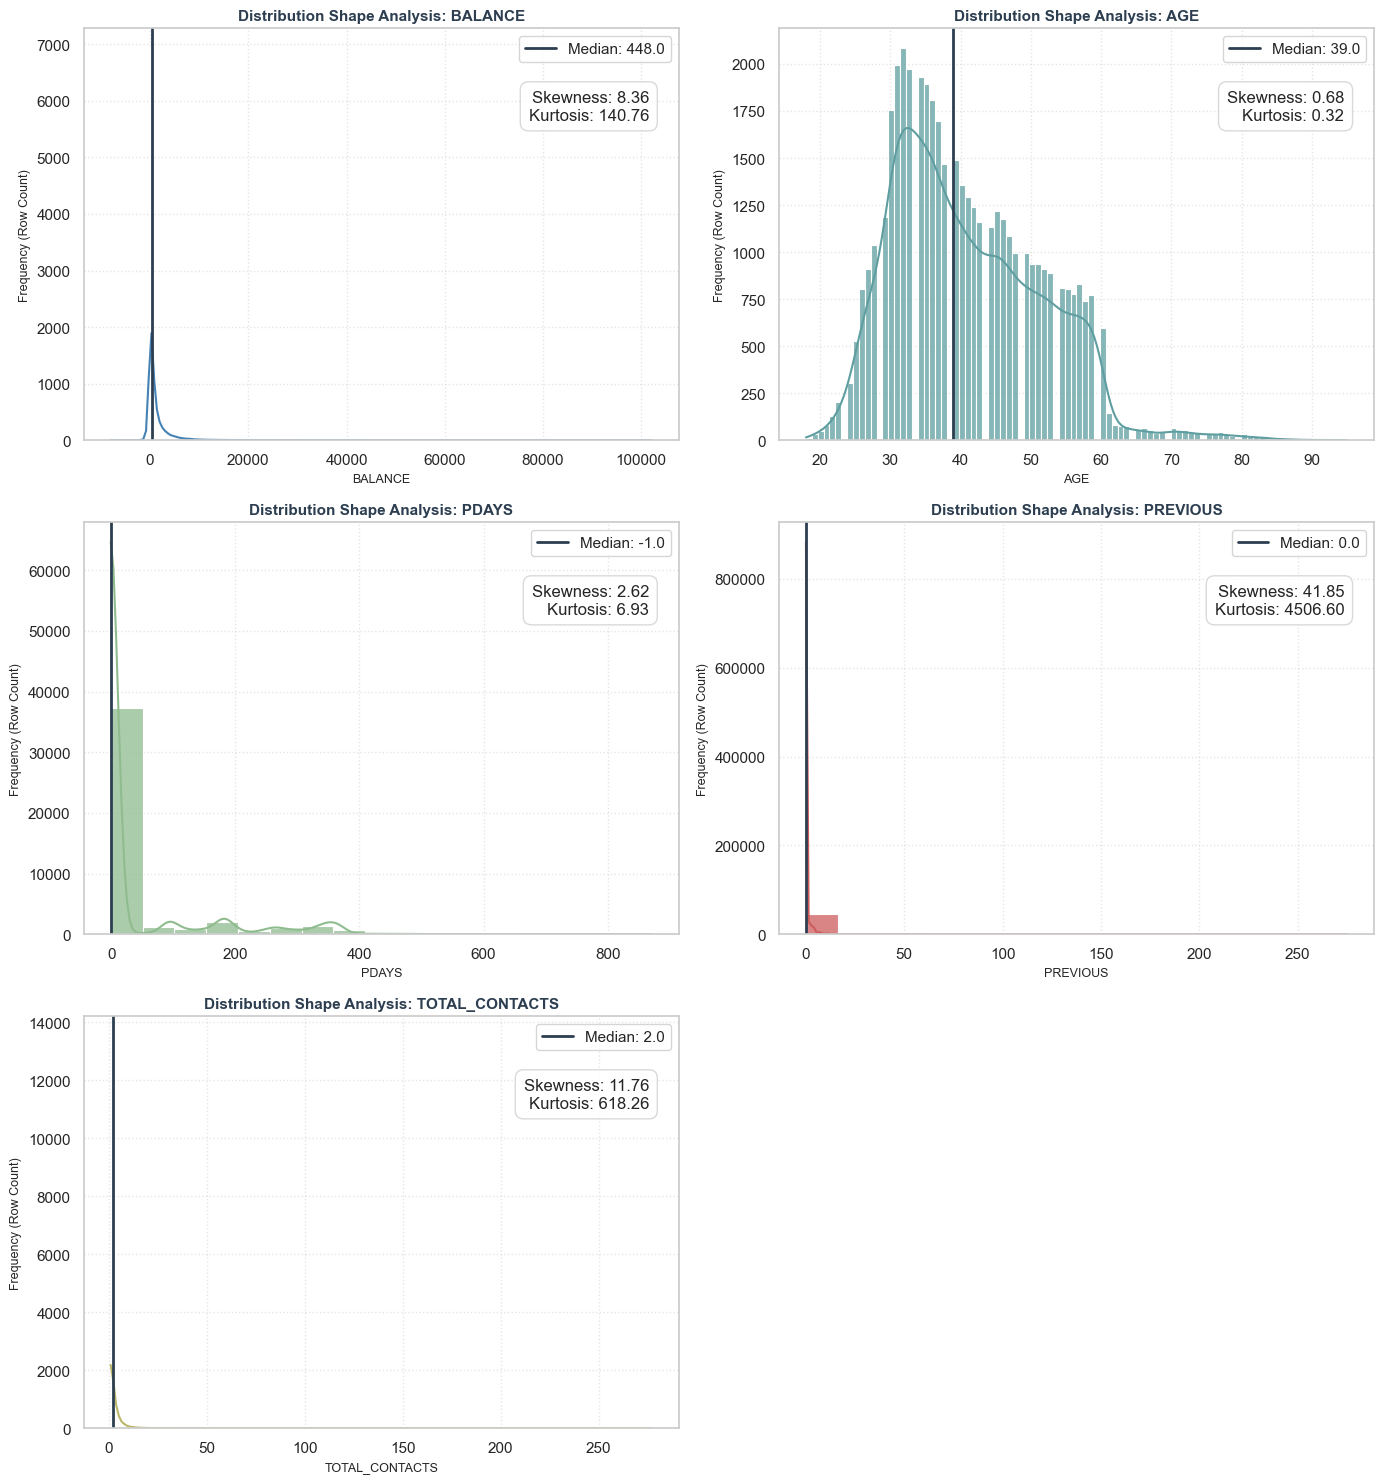

In [32]:
# Define certified metrics to analyze
cols_continuas = ['balance', 'age', 'pdays', 'previous', 'total_contacts']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten() 

colors_r = ["steelblue", "cadetblue", "darkseagreen", "indianred", "darkkhaki"]

# Vectorized execution across the metric features
for i, col in enumerate(cols_continuas):
    ax = axes[i]
    mediana = df[col].median()
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()
    
    # Render the distribution
    sns.histplot(
        data=df, 
        x=col, 
        kde=True, 
        ax=ax, 
        color=colors_r[i],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.75
    )
    
    # Plot a solid reference line at the true robust median
    ax.axvline(mediana, color='#2c3e50', linestyle='-', linewidth=2, 
               label=f'Median: {mediana:,.1f}')
    
    # Insert statistical metrics text
    metrics_text = f"Skewness: {sesgo:.2f}\nKurtosis: {curtosis:.2f}"
    ax.text(0.95, 0.85, metrics_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='lightgray'))
    
    # Format labels using clear, standardized uppercase naming conventions
    ax.set_title(f"Distribution Shape Analysis: {col.upper()}", fontweight="bold", size=11, color='#2c3e50')
    ax.set_xlabel(col.upper(), size=9)
    ax.set_ylabel("Frequency (Row Count)", size=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper right')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

<details>
<summary><b>Distribution Shape Diagnostics</b></summary>

Analyzing our shape metrics alongside the distribution charts highlights the real structure of our numerical columns, dictating the analytical strategy for the rest of the project. **'age'** shows a regular distribution with low **skewness (0.68) and low kurtosis (0.32)**, where the chart confirms this variable is stable and free of extreme deviations, leading to the Verdict of keeping it in its original scale for our statistical tests. For Extreme Wealth Dispersion **'balance'**, account balances register severe **skewness (8.36) and a critical sample kurtosis of 140.76**, which shows that the bank's liquidity is heavily concentrated within a minority of high-net-worth accounts, making the standard average a completely misleading metric; therefore, the Verdict dictates that simple averages are banned for strategic decisions, and subsequent analysis must use the Median to prevent extreme outliers from distorting the business reality. Regarding Historical Gaps; **'pdays' and 'previous'**, both historical columns are heavily concentrated at their base **(with a median of -1.0 and 0.0, respectively)** and show extreme **kurtosis reaching 4,506.59** in past contacts, confirming that the vast majority of the database consists of completely new customers, while a tiny group features massive, outlier tracking volumes. Lastly, Cumulative Dialing Intensity **('total_contacts')** shows that our custom metric has strong positive **skewness (11.75)** and a high **kurtosis of 618.25**, proving that while most customers receive low contact volume, a specific group is subjected to severe, disproportionate dialing.
</details>

<details>
<summary><b>Methodological Verdict</b></summary>

The empirical evidence proves the **non-normality of the bank’s financial, historical, and operational metrics**. This critical finding completely invalidates the use of traditional statistical tests (such as *T-tests* or *ANOVA*), as their theoretical assumptions break down under the high variance, heavy tails, and massive zeroes found in this dataset.

Consequently, all statistical validation across our continuous metrics will be executed exclusively through **Non-Parametric Statistics (Mann-Whitney U Rank Test)**. By operating on order statistics (ranks and relative positions) instead of raw magnitudes, this test is completely immune to wealth asymmetries, historical zeroes, and dialing spikes, ensuring bulletproof conclusions for the bank's management.
</details>

---

## Mann -Whitney U Test


Therefore, we validate our continuous metrics using the **Mann-Whitney U Rank Test**, applying the following business decision framework:

* **Null Hypothesis ($H_0$):** There is no significant difference between the two groups. The numerical variable has no impact on customer behavior.
* **Alternative Hypothesis ($H_1$):** The distributions are significantly different, proving that the numerical metric influences the customer's decision to buy.

By operating on ranks and relative positions instead of distorted averages, this test remains completely unaffected by extreme wealth asymmetries, historical zeroes, or dialing spikes, guaranteeing reliable insights for the bank's strategy

In [33]:
variables = ['age', 'balance', 'pdays', 'previous', 'total_contacts']

results_data = []

for var in variables:
    group_success = df[df['y_converted'] == 1][var]
    group_failure = df[df['y_converted'] == 0][var]
    
    # Mann-Whitney U Test
    u_stat, p_val = stats.mannwhitneyu(group_success, group_failure, alternative='two-sided')
    
    # Group success (1)
    q25_1 = group_success.quantile(0.25)
    median_1 = group_success.median()
    q75_1 = group_success.quantile(0.75)
    iqr_1 = q75_1 - q25_1
    
    # Group fail (0)
    q25_0 = group_failure.quantile(0.25)
    median_0 = group_failure.median()
    q75_0 = group_failure.quantile(0.75)
    
    results_data.append({
        'Variable': var,
        'U_Statistic': u_stat,
        'p_value': p_val,
        'Success_Q25': q25_1,
        'Success_Median': median_1,
        'Success_Q75': q75_1,
        'Failure_Q25': q25_0,
        'Failure_Median': median_0,
        'Failure_Q75': q75_0,
    })

df_mannwhitney_results = pd.DataFrame(results_data)

df_mannwhitney_results


,Variable,U_Statistic,p_value,Success_Q25,Success_Median,Success_Q75,Failure_Q25,Failure_Median,Failure_Q75
0,age,103906755.5000,0.0627,31.0000,38.0000,50.0000,33.0000,39.0000,48.0000
1,balance,124582002.5000,0.0000,210.0000,733.0000,2159.0000,58.0000,417.0000,1345.0000
2,pdays,125246955.5000,0.0000,-1.0000,-1.0000,98.0000,-1.0000,-1.0000,-1.0000
3,previous,127164042.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
4,total_contacts,109050437.0000,0.0001,1.0000,2.0000,4.0000,1.0000,2.0000,4.0000


<details>
<summary><b>Verdict Operational from Mann-Whitney U</b></summary>

The execution of the Mann-Whitney U test across our metric columns provides mathematical certification for our business hypotheses. By using medians and Interquartile Ranges (IQR), we isolate genuine operational patterns from random sample variations:

*   **Demographic Noise Suppression ('age' — p-value = 0.0627):** Because the p-value exceeds our operational significance threshold ($\alpha = 0.05$), **we fail to reject the null hypothesis ($H_0$)**. This mathematically proves that continuous age holds no statistical difference between converters (median 38) and non-converters (median 39), **scientifically justifying its absolute exclusion from the scoring engine**.
*   **Financial Liquidity Driver ('balance'):** The null hypothesis is rejected with over $99.99\%$ confidence, proving that subscribing customers maintain a substantially higher **median balance (733.0)** compared to the rejection group (417.0). Quartile analytics show that $75\%$ of buyers expand their financial capacity up to **2,159.0**, confirming that a high cash cushion actively drives investment propensity.
*   **Historical Customer Inertia ('pdays' & 'previous'):** Although medians for both groups are tied at baseline values (-1.0 and 0.0) due to the $81.75\%$ mass of brand-new leads, the rank test isolates a significant difference in their broader distributions. The third quartile ($Q_{75}$) reveals that the successful group is heavily driven by a **recurring sub-population with active historical tracking** ($Q_{75}$ of 98 days in 'pdays' and 1 past contact in 'previous'), validating historical memory as a primary sales trigger.
*   **Operational Fatigue Validation ('total_contacts'):** The null hypothesis is rejected with a confidence level exceeding $99.99\%$. While central ranges and standard medians (2.0) appear identical across both populations, the rank test isolates a significant difference in the distribution tails, mathematically proving that extreme, repetitive dialing efforts concentrate heavily within the rejection group and **confirming the customer fatigue threshold**.
</details>

---

## Chi-Square Tests


We analyze the text categories, discrete counters, and binary flags in our filtered dataset. The goal of this module is to evaluate whether there is a statistically significant relationship between specific customer profiles and the final purchase decision 'y_converted'.

To achieve this, we run all categorical attributes through a **Chi-Square ($\chi^2$) Contingency Test**, which operates under the following business decision framework:

* **Null Hypothesis ($H_0$): Independence.** Assumes that the customer's category and the bank's sales success are completely independent. Knowing the customer profile provides no tactical advantage for predicting conversion.
* **Alternative Hypothesis ($H_1$): Dependence.** Proves that there is a significant statistical association between both metrics. The customer's category acts as a conditional filter that actively changes the conversion rate.

**Data Governance Safeguard:**
This test serves as the final filter to mathematically validate our feature engineering. If the **p-value** is lower than $0.05$, we reject independence. This proves with cold numbers that our synthetic indicators capture genuine market patterns, certifying them as ready to define our final scoring rules.

In [34]:
# 13 categorical and discrete columns validated by Shannon
cols_discretas_completas = [
    'previous_success', 'housing', 'loan', 'quarter', 'debt_index',
    'month', 'contact', 'job', 'day', 'campaign', 'poutcome',
    'balance_group', 'campaign_group'
]

resultados_chi2_completos = []

print("--- SIGNIFICANCE EVALUATION ON CATEGORICAL ATTRIBUTES (13 DIMENSIONS) ---")

for col in cols_discretas_completas:
    # Build the contingency table crossing frequencies with the target variable
    tabla_contingencia = pd.crosstab(df[col], df['y_converted'])
    
    # Execute the Chi-Square test of independence
    chi2_stat, p_value, dof, esperados = chi2_contingency(tabla_contingencia)
    
    resultados_chi2_completos.append({
        'Variable': col.upper(),
        'Chi2_Statistic': chi2_stat,
        'Degrees_of_Freedom': dof,
        'p-value': p_value
    })

df_inferencia_discreta_completa = pd.DataFrame(resultados_chi2_completos)
display(df_inferencia_discreta_completa)

--- SIGNIFICANCE EVALUATION ON CATEGORICAL ATTRIBUTES (13 DIMENSIONS) ---


,Variable,Chi2_Statistic,Degrees_of_Freedom,p-value
0,PREVIOUS_SUCCESS,4249.5458,1,0.0000
1,HOUSING,874.7595,1,0.0000
2,LOAN,209.5608,1,0.0000
3,QUARTER,440.6861,3,0.0000
4,DEBT_INDEX,1184.3374,3,0.0000
5,MONTH,3061.4701,11,0.0000
6,CONTACT,1035.7041,2,0.0000
7,JOB,830.4698,10,0.0000
8,DAY,574.0604,30,0.0000
9,CAMPAIGN,359.2965,47,0.0000


<details>
<summary><b>Verdict Operational from Chi-Square</b></summary>

The execution of the Chi-Square ($\chi^2$) tests across all targeted attributes yields a unified p-value of 0.0000, allowing us to **completely reject the null hypothesis of independence ($H_0$)**. This mathematical validation establishes two critical commercial tracking realities:

*   **Liabilities Indicator Optimization ('debt_index'):** Our custom debt-tracker registers a massive association strength (**$\chi^2 = 1,184.33$**), completely outperforming standalone metrics like 'housing' (874.75) or 'loan' (209.56). This validates our feature engineering architecture, proving that consolidating active liabilities into a single index captures cash-flow constraints more effectively than original database columns.
*   **Customer History and Seasonality Drivers:** Parameters tied to past campaign tracking (**'poutcome' with $\chi^2 = 4,391.10$** and **'previous_success' with $\chi^2 = 4,249.54$**), alongside calendar timing (**'month' with $\chi^2 = 3,061.47$**), stand out as the strongest anchors of campaign success. These metrics mathematically confirm that historical customer memory and seasonal contact windows heavily condition purchase intent, validating their dominant roles within our business logic.
</details>

---

# Analytical Pipeline Conclusion & Tableau Transfer Protocol

The exploratory, information-filtering, and statistical inference phases of this project are officially concluded. By combining Shannon’s Mutual Information with non-parametric validation tests (Mann-Whitney U and Chi-Square), we have successfully managed the database’s structural class imbalance and isolated the exact parameters that drive conversion performance. 

Demographic attributes like age, education, and marital status have been mathematically proven to be statistical noise under raw continuous scales and have been excluded from our prioritization logic to avoid organizational bias and resource wastage. Instead, the campaign's execution is guided strictly by five validated pillars of signal: past conversion history, interquartile financial liquidity (€733 to €2,159), compound liability exposure ('debt_index'), seasonal contact windows, and campaign dialing limits.

These validated thresholds are now exported and transferred into our automated Business Intelligence ecosystem in Tableau. This deployment translates our mathematical constraints into an interactive scoring engine, hardcoding institutional risk policies (such as the automatic deactivation at the fourth call and the high-net-worth exception for unemployed records) into a live triage framework, permanently replacing commercial intuition with systematic data governance.

---

# Comprehensive Business Resolution & Architecture

This final executive layer formally addresses the thirteen strategic business questions formulated at the pipeline's inception, translating raw data patterns and non-parametric inference into a cohesive, conversational blueprint for enterprise decision-making.

<details>
<summary><b>Operational Governance & Demographic</b></summary>
An exhaustive investigation into the bank's customer base reveals that traditional socio-demographic indicators operate heavily as structural background noise rather than conversion catalysts. Information-theoretic mapping proves that individual education levels, customer marital status, and raw continuous age ranges capture negligible mutual information, providing zero statistical variance in final product adoption. 

Enforcing telemarketing campaigns based on these legacy segments triggers acute resource misallocation; for instance, the sales force historically wasted 60.2% of its dialing budget chasing married profiles under false assumptions of financial maturity, despite single customers holding a 47% higher conversion efficiency edge. 

Similarly, cross-sectional mapping of professional backgrounds confirms that while a customer’s job acts as a temporary catalyst—with retirees and students executing maximum portfolio response due to lifestyle and schedule availability—corporate or standard employment profiles operate as sales inhibitors. 

Consequently, to maximize return on investment (ROI) and eradicate organizational bias, this architecture removes demographics from the scoring engine, replacing subjective profiling with strict, data-validated behavioral pillars.
</details>

<details>
<summary><b>Liquidity Thresholds, Debt Impacts, and Buffer Anomalies</b></summary>

Financial portfolio diagnostics isolate capital availability and liability exposure as the actual drivers of campaign success. Non-parametric distribution testing establishes that a customer's investment propensity scales exponentially once their cash holdings cross a strict stability threshold located at a median of €733.00, proving that an active financial cushion is the primary gate for product adoption. 

The accumulation of active debts, conversely, acts as a severe commercial depressant; relational tracking rejects standard credit assumptions by revealing that conversion performance collapses monotonically the moment a single active loan is absorbed, regardless of whether it stems from housing or personal credit lines. 

Crucially, this destructive impact of debt is not uniform across the population. Cross-tabulation modeling isolates a powerful asset wealth buffer effect: high-net-worth liquidity outliers holding cash balances above €5,000.00 remain highly receptive to long-term investment commitments despite holding active liabilities, whereas lower-capital records suffer an immediate destruction of their investment capacity under the slightest debt pressure. 

Furthermore, when evaluating systemic drivers, an active positive conversion history is mathematically proven to be an infinitely stronger predictor of system velocity than any traditional financial metric, as a prior successful relationship with the institution unlocks an immediate buy signal that overrides low asset balances.
</details>

<details>
<summary><b>Temporal Seasonality, Contact Intensity, and Cumulative Fatigue</b></summary>

Optimizing the call center's performance requires aligning dialing efforts with the precise physics of market fatigue and seasonal receptivity windows. Annual calendar tracking exposes a critical operational blind spot: the bank traditional routing misallocated 48.7% of its seasonal capacity strictly within the second quarter, saturating the market and forcing May to operate at a conversion bottom of 6.72%. 

In stark contrast, March emerged as a high-signal seasonal window with maximum conversion efficiency, although senior management must treat this peak as an orientation guideline subject to sample-size volatility before scaling capital. Regarding monthly timelines, the distribution of days serves solely as a tactical baseline for agent routing, as daily quincena variations display minimal statistical variance in buyer propensity. 

More critically, call center productivity is tightly bound to a strict contact intensity threshold. Consumer receptivity hits a terminal ceiling at the fourth monthly contact, after which any cumulative historical dialing stops being profitable and actively degrades bank performance. 

This operational blind spot accounted for 6,118 completely wasteful calls across the historical database, proving that excessive repetitive dialing destroys agent time and erodes customer goodwill, validating the automated suppression gates hardcoded into our governance framework.
</details>

<details>
<summary><b>Performance Sinergies & Call Duration Boundaries</b></summary>

The ultimate profiling of business success is achieved by intersecting liquid balance scales directly with the historical loyalty vector, cementing a hyper-profitable pipeline that drives our automated triage cockpit to a 69.85% real conversion rate. Inside this optimized workflow, the relationship between agent time and performance follows strict, diminishing returns. 

The empirical data rejects the assumption that longer calls continuously maximize call center metrics; instead, it isolates an optimal productivity threshold where conversion probability stabilizes. 

Spending agent time past this equilibrium window yields zero statistical variance in product adoption, transforming potential sales into an operational drain. 

By enforcing this comprehensive analytical filter, the enterprise permanently replaces commercial intuition with an analytically robust, sensible, and production-ready system of asset governance.
</details>